# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal de clasificación con **Keras 3**.

En este ejercicio vas a aplicar la misma receta sobre un dataset diferente:

> **Olivetti Faces**

El dataset contiene imágenes de rostros en escala de grises. El objetivo será identificar a cuál persona pertenece cada imagen.

No necesitas diseñar un pipeline de datos nuevo. La carga, división y visualización están resueltas.

Tu trabajo se concentra en completar las etapas principales de Keras:

```text
Datos
  ↓
Modelo
  ↓
Loss + Optimizer
  ↓
Entrenamiento
  ↓
Evaluación
  ↓
Predicción
```

---

## ¿Qué debes completar?

Las celdas marcadas con `# TODO` contienen espacios que debes completar.

El resto del código está preparado para que puedas concentrarte en los conceptos vistos en clase.


---
## 0. Importar librerías

Usaremos:

- **Keras 3** para construir y entrenar la red.
- **scikit-learn** para cargar Olivetti Faces y dividir los datos.
- **NumPy** para manipular arrays.
- **Matplotlib** para visualizar imágenes.


In [1]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: Olivetti Faces

Olivetti Faces contiene:

- **400 imágenes**
- imágenes de **64 × 64 píxeles**
- escala de grises
- **40 personas**
- **10 imágenes por persona**

La etiqueta indica la identidad de la persona:

```text
0, 1, 2, ..., 39
```

Cada imagen ya viene representada con valores flotantes aproximadamente en el rango:

$$
[0,1]
$$

Por eso, en este ejercicio **no necesitamos normalizar dividiendo por 255**.


In [2]:
# Esta parte está resuelta.

faces = fetch_olivetti_faces(
    shuffle=True,
    random_state=SEED
)

X = faces.images
y = faces.target

print("X:", X.shape)
print("y:", y.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Número de clases:", len(np.unique(y)))


X: (400, 64, 64)
y: (400,)
Valor mínimo: 0.0
Valor máximo: 1.0
Número de clases: 40


## 1.1 Dividir entrenamiento y prueba

Como solo tenemos 10 imágenes por persona, debemos asegurarnos de que todas las identidades aparezcan tanto en entrenamiento como en prueba.

Usaremos una división **estratificada**:

```text
80% entrenamiento
20% prueba
```

La opción:

```python
stratify=y
```

mantiene la proporción de cada clase en ambos conjuntos.

Esta parte está resuelta.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nPersonas en train:", len(np.unique(y_train)))
print("Personas en test :", len(np.unique(y_test)))


X_train: (320, 64, 64)
X_test : (80, 64, 64)
y_train: (320,)
y_test : (80,)

Personas en train: 40
Personas en test : 40


### Pregunta 1

Cada imagen tiene tamaño:

$$
64 \times 64
$$

Cuando apliquemos `Flatten()`, ¿cuántos valores tendrá cada ejemplo?

**Respuesta:** $64\times64=$ **4096 valores** por ejemplo.



---
## 1.2 Visualizar algunas imágenes

Esta parte está resuelta.

Observa que varias fotografías corresponden a la misma persona con pequeñas variaciones de expresión, iluminación y orientación.


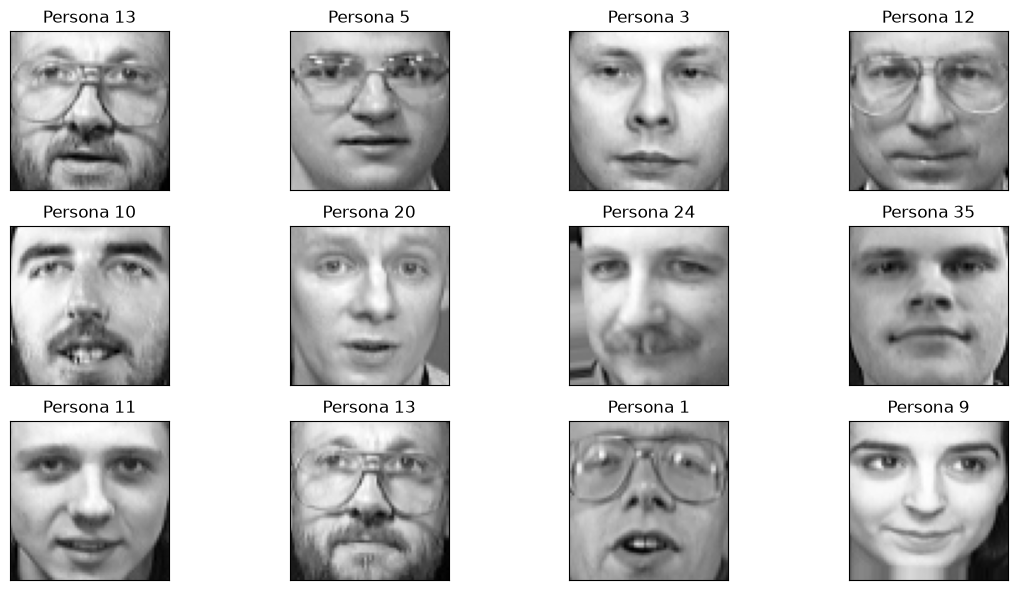

In [4]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Persona {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Usaremos una arquitectura fully-connected similar a la vista en clase:

```text
Imagen 64×64
     ↓
Flatten
     ↓
4096 valores
     ↓
Dense(64)
     ↓
ReLU
     ↓
Dense(40)
     ↓
Logits
```

La última capa debe tener una salida por cada clase.

> **Importante:** no añadas `Softmax` al final. Trabajaremos directamente con **logits**.


In [5]:
# TODO 1 — Completar la arquitectura.

model = keras.Sequential([

    keras.Input(shape=(64, 64)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(40)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,808 (1.01 MB)

 Trainable params: 264,808 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Validación TODO 1

assert isinstance(model, keras.Model)

# Dense(64): 4096*64 + 64
# Dense(40): 64*40 + 40
expected_params = (4096 * 64 + 64) + (64 * 40 + 40)

assert model.count_params() == expected_params, (
    f"Se esperaban {expected_params:,} parámetros, "
    f"pero el modelo tiene {model.count_params():,}."
)

print("✓ Arquitectura correcta.")
print(f"Parámetros entrenables: {model.count_params():,}")


✓ Arquitectura correcta.
Parámetros entrenables: 264,808


### Pregunta 2

¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Porque `Dense` opera sobre un vector por ejemplo ($W\mathbf{x}+\mathbf{b}$). `Flatten()` transforma cada imagen $64\times64$ en un vector de 4096 componentes, sin parámetros.

### Pregunta 3

¿Por qué la última capa tiene **40 neuronas**?

**Respuesta:** Porque hay **40 personas** (clases 0–39): una neurona/logit por identidad.

### Pregunta 4

¿Qué función cumple `ReLU` en la capa oculta?

**Respuesta:** Introduce no linealidad, $\max(0,x)$, para que la red no colapse en una sola transformación lineal. Este ejercicio muestra también su punto débil: si la pre-activación es negativa para todos los ejemplos, la salida y el gradiente valen 0 y la neurona deja de aprender (*dying ReLU*, ver diagnóstico).



---
# 3. Configurar el entrenamiento

Las etiquetas son números enteros entre:

```text
0 y 39
```

Por eso usaremos:

```python
SparseCategoricalCrossentropy
```

Además:

- el modelo produce **logits**,
- usaremos **Adam**,
- mediremos **accuracy**.

Completa `model.compile()`.


In [7]:
lr_rate = 0.001

# TODO 2 — Configurar loss, optimizer y métrica.

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=lr_rate
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)

print("✓ Modelo configurado.")


✓ Modelo configurado.


### Pregunta 5

¿Por qué usamos:

```python
from_logits=True
```

en la función de pérdida?

**Respuesta:** Porque `Dense(40)` devuelve **logits**, no probabilidades. `from_logits=True` indica a la pérdida que aplique Softmax internamente, de forma numéricamente estable, antes de calcular la cross-entropy.



---
# 4. Entrenar el modelo

Usaremos:

```python
epochs = 30
batch_size = 32
```

El dataset es pequeño, por lo que el entrenamiento debería ser rápido.

Keras realizará internamente:

```text
Forward pass
      ↓
Calcular loss
      ↓
Backpropagation
      ↓
Actualizar parámetros con Adam
```

Completa la llamada a `fit()`.


In [8]:
epochs = 30
batch_size = 32

# TODO 3 — Entrenar el modelo.

history = model.fit(

    X_train,
    y_train,

    epochs=epochs,
    batch_size=batch_size,

    validation_data=(X_test, y_test),

    shuffle=True
)


Epoch 1/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.0312 - loss: 3.7614

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0156 - loss: 3.9050 - val_accuracy: 0.0250 - val_loss: 3.6889


Epoch 2/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0312 - loss: 3.6883

...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0312 - loss: 3.6885

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0250 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889


Epoch 30/30


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0312 - loss: 3.6885

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0250 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889


### Pregunta 6

¿Qué representa una **epoch**?

**Respuesta:** Una pasada completa por las 320 imágenes de entrenamiento.

### Pregunta 7

¿Qué significa `batch_size=32`?

**Respuesta:** Que cada actualización de pesos usa 32 imágenes; por eso cada epoch tiene $320/32=10$ actualizaciones.



---
## 4.1 Visualizar el entrenamiento

Esta parte está resuelta.

El dataset tiene muy pocos ejemplos comparado con el número de parámetros de la red.

Observa cuidadosamente la diferencia entre entrenamiento y validación.


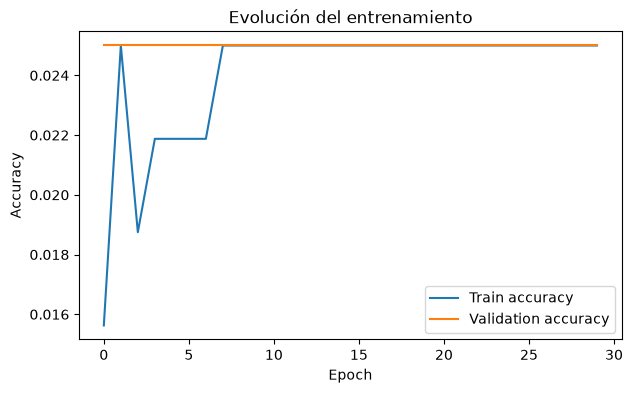

In [9]:
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()

plt.show()


### Pregunta 8

Observando la gráfica:

- ¿El accuracy de entrenamiento sigue aumentando?
- ¿El accuracy de validación se comporta igual?
- ¿Observas evidencia de **overfitting**?

**Respuesta:** **Con la configuración pedida, ninguna curva aumenta.** El accuracy de entrenamiento y el de validación quedan fijos en 0.025 (= 1/40) durante las 30 epochs y la pérdida en 3.689 ≈ $\ln 40$. **No hay overfitting, sino un modelo que no aprendió nada**: las 64 neuronas ReLU de la capa oculta quedaron muertas (64/64; ver diagnóstico adicional) y la red produce la misma salida para cualquier cara.

En el diagnóstico, centrando las entradas y sin cambiar nada más, sí aparece el comportamiento esperado: el accuracy de entrenamiento llega a **1.00** mientras que el de validación se queda en **0.95**, y la pérdida de validación (0.265) es unas 25 veces la de entrenamiento (0.011). Eso sí es **evidencia de overfitting**: la red memoriza el set de entrenamiento.



---
# 5. Evaluar el modelo

Ahora evaluaremos el modelo sobre imágenes que no fueron utilizadas para actualizar sus parámetros.

Completa `evaluate()`.


In [10]:
# TODO 4 — Evaluar.

test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,

    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 3.6889
Test accuracy : 0.0250
Accuracy (%)  : 2.50%


---
## Diagnóstico adicional (no pedido por el taller): ¿por qué la red no aprende?

Con la configuración pedida (Adam `lr=0.001`, 30 epochs, batch 32) la pérdida queda en $\ln 40\approx3.689$ y el accuracy en $1/40=2.5\%$, es decir, azar. La red predice prácticamente la misma distribución para todas las caras.

**Hipótesis:** *dying ReLU*. Las entradas están en $[0,1]$ (todas positivas, sin centrar) y hay 4096 por neurona; las primeras actualizaciones de Adam empujan los sesgos y pesos de la capa oculta a valores donde la pre-activación es negativa para **todas** las imágenes. Entonces ReLU devuelve 0, su gradiente también es 0 y esas neuronas no se recuperan.

Abajo se verifica la hipótesis y se repite el entrenamiento cambiando **una sola cosa**: centrar los píxeles restando la media de entrenamiento. Arquitectura, optimizador, epochs y batch no cambian. La solución pedida en los TODO **no se modifica**: esto es solo para interpretar el resultado.

In [11]:
# 1) ¿Cuántas neuronas ocultas quedaron "muertas" (salida 0 para todas las imágenes de train)?
def hidden_activations(m, X):
    # Salida de Dense(64)+ReLU calculada a mano: relu(x·W + b)
    W, b = m.layers[1].get_weights()
    return np.maximum(0, X.reshape(len(X), -1) @ W + b)

h_train = hidden_activations(model, X_train)
dead = np.all(h_train == 0, axis=0)
print(f"Neuronas ReLU muertas en la capa Dense(64): {dead.sum()} de {dead.size}")

Neuronas ReLU muertas en la capa Dense(64): 64 de 64


Neuronas muertas con entradas centradas: 0 de 64
Train accuracy (última epoch): 1.0000 | train loss: 0.0107
Test accuracy                : 0.9500 | test loss : 0.2648


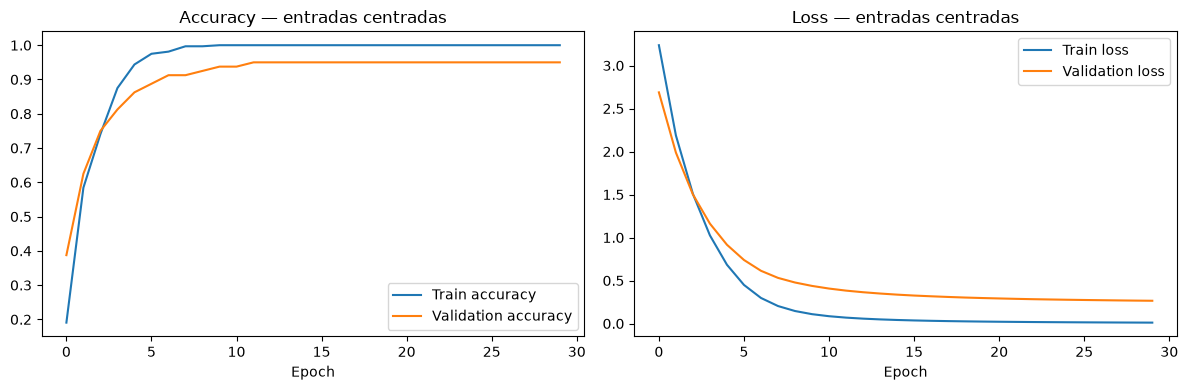

In [12]:
# 2) Mismo modelo y mismo entrenamiento, con entradas centradas
keras.utils.set_random_seed(SEED)

pixel_mean = X_train.mean(axis=0)          # media calculada SOLO con train
X_train_c = X_train - pixel_mean
X_test_c = X_test - pixel_mean

model_centered = keras.Sequential([
    keras.Input(shape=(64, 64)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(40),
])
model_centered.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
history_c = model_centered.fit(
    X_train_c, y_train,
    epochs=epochs, batch_size=batch_size,
    validation_data=(X_test_c, y_test),
    shuffle=True, verbose=0,
)

h_c = hidden_activations(model_centered, X_train_c)
print("Neuronas muertas con entradas centradas:", int(np.all(h_c == 0, axis=0).sum()), "de 64")

loss_c, acc_c = model_centered.evaluate(X_test_c, y_test, verbose=0)
print(f"Train accuracy (última epoch): {history_c.history['accuracy'][-1]:.4f} | train loss: {history_c.history['loss'][-1]:.4f}")
print(f"Test accuracy                : {acc_c:.4f} | test loss : {loss_c:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_c.history["accuracy"], label="Train accuracy")
axes[0].plot(history_c.history["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Accuracy — entradas centradas"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history_c.history["loss"], label="Train loss")
axes[1].plot(history_c.history["val_loss"], label="Validation loss")
axes[1].set_title("Loss — entradas centradas"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

### Pregunta 9

Tenemos **40 clases**, pero solamente **320 imágenes de entrenamiento**.

¿Crees que la cantidad de datos es grande o pequeña para una red con cientos de miles de parámetros?

**Respuesta:** **Pequeña.** 320 imágenes (8 por persona) para ajustar 264 808 parámetros: unos 830 parámetros por imagen de entrenamiento. Con tantos grados de libertad la red puede memorizar cada foto en vez de aprender rasgos generales del rostro, y una variación de iluminación o expresión no vista puede confundirla.



---
# 6. Logits y Softmax

La salida de nuestro modelo tiene forma:

```text
(batch_size, 40)
```

Cada uno de los 40 valores corresponde al **logit** asociado a una persona.

Los logits no son probabilidades.

Para convertirlos en probabilidades usamos:

```python
keras.ops.softmax(...)
```


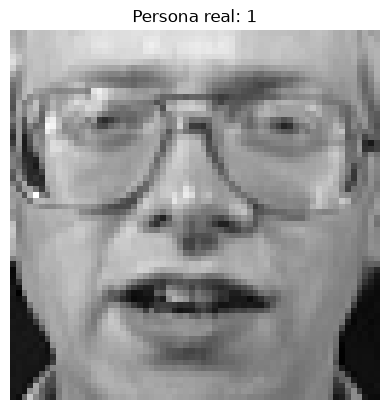

Shape de logits: (1, 40)

Primeros 10 logits:
[ 0.00078378 -0.00700768  0.00334249 -0.00296516 -0.00047904 -0.00141983
 -0.00902546  0.00582534 -0.00014707  0.00095134]


In [13]:
index = 0

image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Persona real: {true_class}")
plt.axis("off")
plt.show()

# Añadimos dimensión de batch:
# (64,64) -> (1,64,64)
image_batch = np.expand_dims(image, axis=0)

# Forward pass.
logits = model(
    image_batch,
    training=False
)

print("Shape de logits:", logits.shape)
print("\nPrimeros 10 logits:")
print(
    keras.ops.convert_to_numpy(logits)[0, :10]
)


In [14]:
# TODO 5 — Convertir logits a probabilidades.

probabilities = keras.ops.softmax(logits)

# TODO 6 — Obtener la clase con mayor probabilidad.

prediction = keras.ops.argmax(
    probabilities,
    axis=1
)

prediction = int(
    keras.ops.convert_to_numpy(prediction)[0]
)

print()
print("Persona real     :", true_class)
print("Persona predicha :", prediction)



Persona real     : 1
Persona predicha : 10


In [15]:
# Revisamos las cinco clases con mayor probabilidad.

probabilities_np = keras.ops.convert_to_numpy(
    probabilities
)[0]

top5 = np.argsort(
    probabilities_np
)[-5:][::-1]

print("Top 5 predicciones:\n")

for class_id in top5:
    print(
        f"Persona {class_id:2d}: "
        f"{probabilities_np[class_id]:.4f}"
    )

print(
    "\nSuma de probabilidades:",
    probabilities_np.sum()
)


Top 5 predicciones:

Persona 10: 0.0252
Persona 17: 0.0252
Persona  7: 0.0251
Persona 26: 0.0251
Persona 19: 0.0251

Suma de probabilidades: 1.0


### Pregunta 10

¿Por qué la suma de las 40 probabilidades obtenidas con `Softmax` debe ser aproximadamente `1`?

**Respuesta:** Porque Softmax divide cada $e^{z_k}$ entre la suma de los 40 términos, así que las probabilidades son positivas y suman 1. En esta ejecución, como la red quedó muerta, los logits son casi idénticos (≈0.00x) y todas las probabilidades son ≈0.025 = 1/40: la "predicción" (persona 10) es prácticamente un empate.



---
# 7. Visualizar varias predicciones

Esta parte está resuelta.

Observa especialmente los casos en los que el modelo se equivoca.


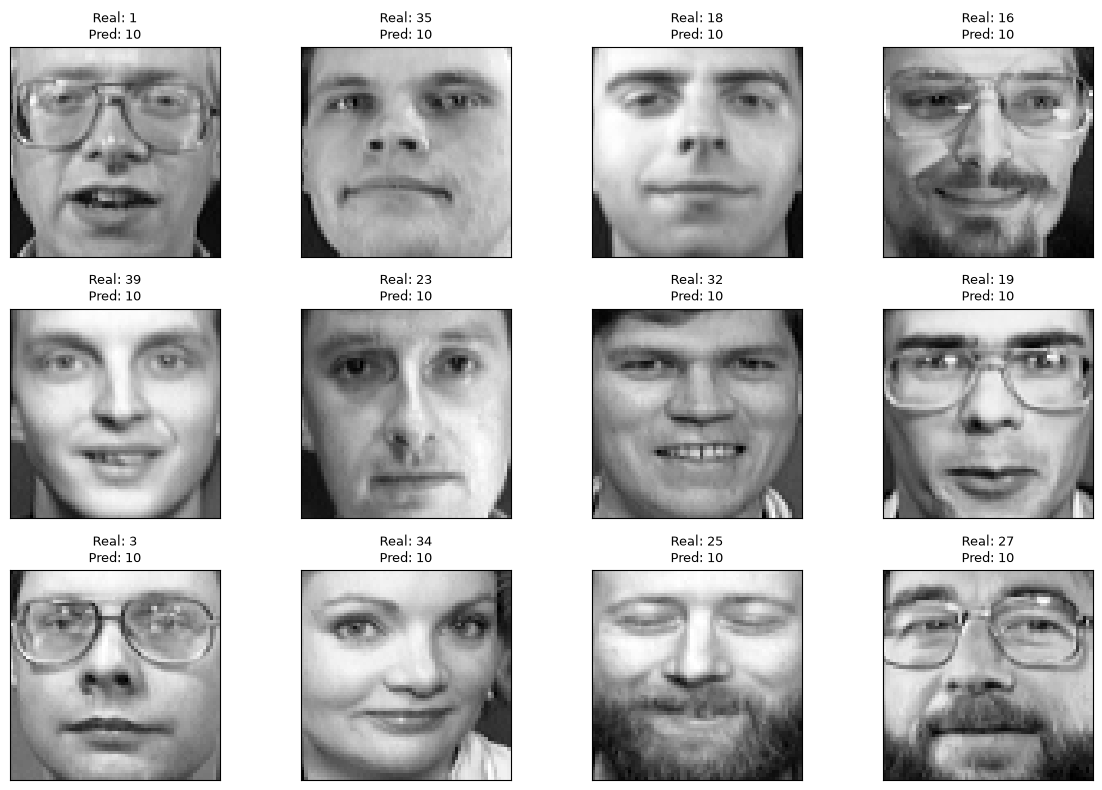

In [16]:
n = 12

logits_batch = model(
    X_test[:n],
    training=False
)

predictions = keras.ops.argmax(
    logits_batch,
    axis=1
)

predictions = keras.ops.convert_to_numpy(
    predictions
)

plt.figure(figsize=(12, 8))

for i in range(n):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    real = y_test[i]
    pred = predictions[i]

    plt.title(
        f"Real: {real}\nPred: {pred}",
        fontsize=9
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 8. Reflexión final

Responde brevemente.

### 1. ¿Cuál fue el accuracy final del modelo?

**Respuesta:** Con la configuración pedida: **2.50 %** en test (loss 3.6889), que es el azar para 40 clases. En el diagnóstico con entradas centradas (mismo modelo y entrenamiento): **95.00 %** en test.

### 2. ¿Observaste overfitting? ¿Qué evidencia utilizaste?

**Respuesta:** Con la configuración pedida, **no**: no hubo aprendizaje (train = validation = 2.5 %); la evidencia es la pérdida constante en $\ln 40$ y 64/64 neuronas muertas. Con entradas centradas **sí**: train 100 % frente a validation 95 % y val_loss 0.265 frente a train loss 0.011.

### 3. ¿Qué ocurre cuando tenemos muchos parámetros pero pocos ejemplos de entrenamiento?

**Respuesta:** El modelo puede **memorizar** los ejemplos de entrenamiento (accuracy 100 %, pérdida casi 0) y generalizar peor: alta varianza y sensibilidad a la partición. Ayudan la regularización (L2, Dropout), early stopping, data augmentation, menos parámetros o reutilizar un modelo preentrenado.

### 4. Después de `Flatten()`, una cara de 64×64 se convierte en un vector de 4096 números.

¿Qué información sobre la estructura de la imagen deja de representar explícitamente esta transformación?

**Respuesta:** Las **relaciones espaciales**: qué píxeles son vecinos, la forma local de ojos, nariz o boca, y su disposición relativa en la cara. Tras `Flatten()` cada píxel es una feature independiente con posición fija; un leve desplazamiento o giro del rostro cambia el vector por completo.

### 5. ¿Crees que una arquitectura diseñada específicamente para imágenes podría aprovechar mejor la información espacial?

**Respuesta:** Sí. Una **CNN** usa filtros locales con pesos compartidos, que detectan el mismo patrón (un borde, un ojo) en cualquier posición y con muchos menos parámetros que una capa densa sobre 4096 píxeles. Eso es especialmente valioso con tan pocos datos.

---

## Para pensar

Nuestra red recibe:

```text
64 × 64
   ↓
Flatten
   ↓
4096 números
   ↓
Dense
```

Pero una imagen tiene una estructura espacial:

- píxeles cercanos están relacionados,
- existen bordes,
- existen formas,
- existen patrones locales.

Una red fully-connected no incorpora explícitamente esa estructura.

Esto motiva una arquitectura diseñada específicamente para imágenes:

> **Convolutional Neural Networks (CNNs)**


---
# Resumen

En este ejercicio aplicaste nuevamente la receta básica de entrenamiento de una red neuronal:

```text
Dataset
   ↓
Train / Test split
   ↓
Sequential
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense(40)
   ↓
Cross-Entropy
   ↓
Adam
   ↓
fit()
   ↓
evaluate()
```

Los componentes de Keras son los mismos que usamos en clase.

Lo que cambió fue:

- el dataset,
- el tamaño de las imágenes,
- el número de clases,
- y la dificultad del problema.
